In [10]:
from pathlib import Path
import re
import pandas as pd
import seaborn as sns

In [11]:
WORKLOADS = ["faiss_10M", "lulesh2.0_s400", "DuckDB-TPCH-sf100", "DuckDB-TPCDS-sf100", "mg.D.x", "XSBench", "pr-kron.sg", "pr-twitter.sg", "bc-kron.sg", "bc-twitter.sg"]

In [12]:
def parse_time_value(raw: str) -> float:
    """Convert strings like '7m56.676s' into seconds."""
    
    raw = raw.strip()
    match = re.fullmatch(r"(?:(\d+)m)?([0-9.]+)s", raw)
    if not match:
        raise ValueError(f"Unrecognized time format: {raw}")
    minutes = int(match.group(1) or 0)
    seconds = float(match.group(2))
    return minutes * 60 + seconds

def parse_time_file(path: Path) -> dict:
    metrics = {}
    with path.open() as f:
        for line in f:
            line = line.strip()
            if not line or "\t" not in line:
                continue
            key, value = line.split("\t", 1)
            metrics[key] = parse_time_value(value)
    return metrics

def extract_mib(path: Path) -> int | None:
    match = re.search(r"(\d+)MiB", path.name)
    return int(match.group(1)) if match else None


def extract_run(path: Path) -> int | None:
    match = re.search(r"run(\d+)", path.name)
    return int(match.group(1)) if match else None

def parse_log_file(path: Path) -> dict:
    metrics = {}
    with path.open() as f:
        for line in f:
            line = line.strip()
            if not line or "=" not in line:
                continue
            key, value = line.split("=", 1)
            metrics[key.strip()] = float(value.strip())
    return metrics

In [13]:
def generate_df(roots_gen: callable) -> pd.DataFrame:
    dfs = []

    for workload in WORKLOADS:
        records: list[dict] = []
        for label, (kernel, root) in roots_gen(workload).items():
            for path in sorted(root.glob("*.time")):
                if "train" in path.name:
                    continue
                metrics = parse_time_file(path)
                try:
                    log_metrics = parse_log_file(Path(f"{path.parent}/max_dram_hugepages_{path.stem}.log"))
                except FileNotFoundError:
                    log_metrics = {}
                    
                m = re.search(
                    r"_discounted_reward_(\d+)_.*_l2-(true|false)_(\d+)_([0-9]*\.?[0-9]+)\.time$",
                    path.name,
                )
                parsed = {}
                if m:
                    parsed = {
                        "discounted_reward": int(m.group(1)),
                        "minmax": m.group(2) == "true",
                        "hist_length": int(m.group(3)),
                        "penalty": float(m.group(4)),
                    }

                records.append({
                    "policy": label,
                    "kernel": kernel,
                    "file": path.name,
                    "MiB": extract_mib(path),
                    "run": extract_run(path),
                    **metrics,
                    **log_metrics,
                    **parsed,
                })

        df = pd.DataFrame(records)
        df["workload"] = workload

        dfs.append(df)
    df = pd.concat(dfs, ignore_index=True)
    return df

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import matplotlib.colors as mcolors
from matplotlib.patches import Patch


def find_policy_name(policy_order: list[str], *aliases: str) -> str | None:
    return next(
        (
            policy
            for policy in policy_order
            if any(alias in policy.lower() for alias in aliases)
        ),
        None,
    )


def describe_manta_gap(manta_time: float, other_time: float) -> str:
    if pd.isna(manta_time) or pd.isna(other_time) or manta_time <= 0 or other_time <= 0:
        return "n/a"
    if manta_time < other_time:
        pct = (other_time - manta_time) / other_time * 100
        speedup = other_time / manta_time
        return f"faster by {pct:.1f}% ({speedup:.2f}x)"
    if manta_time > other_time:
        pct = (manta_time - other_time) / other_time * 100
        slowdown = manta_time / other_time
        return f"slower by {pct:.1f}% ({slowdown:.2f}x runtime)"
    return "tied"


def is_arms_or_manta_policy(policy_name: str) -> bool:
    normalized = policy_name.lower()
    return "arms" in normalized or "manta" in normalized or "model" in normalized


def style_deemphasized_bar(bar, *, fill_alpha: float = 0.5, edge_alpha: float = 0.7, linewidth: float = 0.9) -> None:
    red, green, blue, _ = bar.get_facecolor()
    bar.set_facecolor((red, green, blue, fill_alpha))
    bar.set_edgecolor((red, green, blue, edge_alpha))
    bar.set_linewidth(linewidth)
    bar.set_linestyle("--")


def print_workload_speedups(workload_name: str, workload_df: pd.DataFrame, policy_order: list[str]) -> None:
    manta_policy = find_policy_name(policy_order, "manta", "model")
    arms_policy = find_policy_name(policy_order, "arms")

    if manta_policy is None:
        return

    mean_times = (
        workload_df.groupby(["MiB", "policy"], observed=False)["real"]
        .mean()
        .unstack("policy")
        .reindex(columns=policy_order)
        .sort_index()
    )

    baseline_policies = [
        policy
        for policy in policy_order
        if policy not in {manta_policy, arms_policy}
    ]

    print(f"{workload_name} speedup summary")
    for mib_value, row in mean_times.iterrows():
        manta_time = row.get(manta_policy)
        if pd.isna(manta_time):
            continue

        mib_label = int(mib_value) if pd.notna(mib_value) else "n/a"

        if arms_policy is not None and pd.notna(row.get(arms_policy)):
            arms_time = row[arms_policy]
            arms_summary = (
                f"{manta_policy} vs {arms_policy}: "
                f"{manta_time:.2f}s vs {arms_time:.2f}s -> {describe_manta_gap(manta_time, arms_time)}"
            )
        else:
            arms_summary = f"{manta_policy} vs ARMS: n/a"

        baseline_series = row[baseline_policies].dropna() if baseline_policies else pd.Series(dtype=float)
        if not baseline_series.empty:
            best_baseline_policy = baseline_series.idxmin()
            best_baseline_time = baseline_series.min()
            baseline_summary = (
                f"{manta_policy} vs best baseline ({best_baseline_policy}): "
                f"{manta_time:.2f}s vs {best_baseline_time:.2f}s -> "
                f"{describe_manta_gap(manta_time, best_baseline_time)}"
            )
        else:
            baseline_summary = f"{manta_policy} vs best baseline: n/a"

        print(f"  {mib_label} MiB")
        print(f"    {arms_summary}")
        print(f"    {baseline_summary}")


def plot_df(
    df: pd.DataFrame,
    roots_gen: callable,
    *,
    figsize=(14, 8),
    title=True,
    prefix="",
    dash_non_arms_non_manta: bool = False,
) -> None:

    policy_order = list(roots_gen("").keys())

    color_brewer_palette = ["#e41a1c", "#377eb8", "#4daf4a", "#984ea3", "#ff7f00"]
    policy_palette = {
        policy: color_brewer_palette[index % len(color_brewer_palette)]
        for index, policy in enumerate(policy_order)
    }

    def minmax_interval(values):
        return values.min(), values.max()

    for workload_name, workload_df in df.groupby("workload"):
        print(workload_name)
        plt.figure(figsize=figsize)
        ax = sns.barplot(
            workload_df,
            x="MiB",
            y="real",
            hue="policy",
            hue_order=policy_order,
            palette=policy_palette,
            estimator="mean",
            errorbar=minmax_interval,
        )
        if title:
            ax.set(title=workload_name)
        ax.set_ylabel("Execution Time (s)")
        ax.set_xlabel("Memory Footprint (MiB)", labelpad=2)
        ax.tick_params(axis="x", pad=1)

        stats = (
            workload_df.groupby(["MiB", "policy"], observed=False)["real"]
            .agg(mean="mean", upper="max")
            .reindex(
                pd.MultiIndex.from_product(
                    [sorted(workload_df["MiB"].dropna().unique()), policy_order],
                    names=["MiB", "policy"],
                )
            )
        )

        ymin, ymax = ax.get_ylim()
        value_range = ymax - ymin
        label_offset = max(value_range * 0.025, 0.1)
        label_texts = []

        for policy_index, container in enumerate(ax.containers):
            if policy_index >= len(policy_order):
                break

            policy = policy_order[policy_index]
            should_dash_policy = dash_non_arms_non_manta and not is_arms_or_manta_policy(policy)
            for bar_index, bar in enumerate(container):
                if should_dash_policy:
                    style_deemphasized_bar(bar)
                if bar_index >= len(stats.index.levels[0]):
                    continue

                mib_value = stats.index.levels[0][bar_index]
                bar_stats = stats.loc[(mib_value, policy)]
                if pd.isna(bar_stats["mean"]):
                    continue

                label_y = bar_stats["upper"] + label_offset
                label_texts.append(
                    ax.text(
                        bar.get_x() + bar.get_width() / 2,
                        label_y,
                        f"{bar_stats['mean']:.2f}",
                        ha="left",
                        va="center",
                        fontsize=8,
                        fontweight="bold",
                        rotation=90,
                        rotation_mode="anchor",
                        color="black",
                        clip_on=True,
                        zorder=5,
                        path_effects=[pe.withStroke(linewidth=2.0, foreground="white")],
                    )
                )

        ax.set_ylim(ymin, ymax + label_offset * 3)

        figure = ax.figure
        figure.canvas.draw()
        renderer = figure.canvas.get_renderer()
        axes_bbox = ax.get_window_extent(renderer=renderer)
        padding_px = 4

        for text in label_texts:
            text_bbox = text.get_window_extent(renderer=renderer)
            dx = 0.0
            dy = 0.0

            if text_bbox.x0 < axes_bbox.x0 + padding_px:
                dx = (axes_bbox.x0 + padding_px) - text_bbox.x0
            elif text_bbox.x1 > axes_bbox.x1 - padding_px:
                dx = (axes_bbox.x1 - padding_px) - text_bbox.x1

            if text_bbox.y0 < axes_bbox.y0 + padding_px:
                dy = (axes_bbox.y0 + padding_px) - text_bbox.y0
            elif text_bbox.y1 > axes_bbox.y1 - padding_px:
                dy = (axes_bbox.y1 - padding_px) - text_bbox.y1

            if dx == 0.0 and dy == 0.0:
                continue

            current_x, current_y = text.get_position()
            display_x, display_y = ax.transData.transform((current_x, current_y))
            adjusted_x, adjusted_y = ax.transData.inverted().transform((display_x + dx, display_y + dy))
            text.set_position((adjusted_x, adjusted_y))

        if ax.legend_ is not None:
            ax.legend_.remove()

        plt.tight_layout()
        plt.savefig(f"plots/{prefix}{workload_name}.pdf", bbox_inches="tight")
        plt.show()
        print_workload_speedups(workload_name, workload_df, policy_order)
        print()

    legend_handles = [
        Patch(
            facecolor=mcolors.to_rgba(policy_palette[policy], alpha=0.5)
            if dash_non_arms_non_manta and not is_arms_or_manta_policy(policy)
            else policy_palette[policy],
            edgecolor=mcolors.to_rgba(policy_palette[policy], alpha=0.7)
            if dash_non_arms_non_manta and not is_arms_or_manta_policy(policy)
            else "none",
            linewidth=0.9 if dash_non_arms_non_manta and not is_arms_or_manta_policy(policy) else 0.0,
            linestyle="--" if dash_non_arms_non_manta and not is_arms_or_manta_policy(policy) else "solid",
            label=policy,
        )
        for policy in policy_order
    ]
    legend_width = max(6, 1.8 * len(policy_order))
    _, legend_ax = plt.subplots(figsize=(legend_width, 1.4))
    legend_ax.axis("off")
    legend = legend_ax.legend(
        handles=legend_handles,
        loc="center",
        ncol=len(policy_order),
        frameon=True,
        fancybox=True,
        framealpha=1.0,
        borderpad=0.8,
    )
    legend.get_frame().set_facecolor("white")
    legend.get_frame().set_edgecolor("black")
    legend.get_frame().set_linewidth(1.0)
    plt.tight_layout()
    plt.savefig(f"plots/{prefix}legend.pdf", bbox_inches="tight")
    plt.show()

DuckDB-TPCDS-sf100


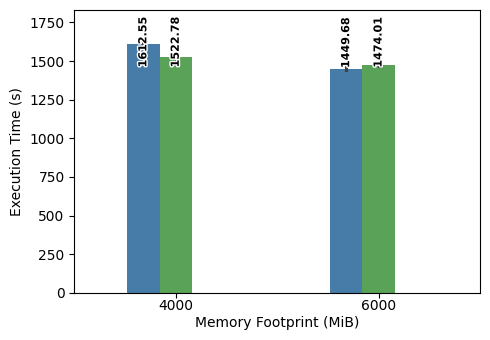

DuckDB-TPCDS-sf100 speedup summary

DuckDB-TPCH-sf100


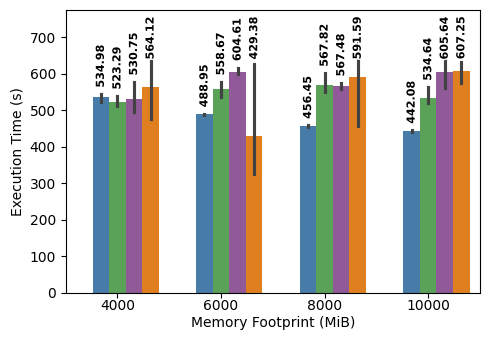

DuckDB-TPCH-sf100 speedup summary

XSBench


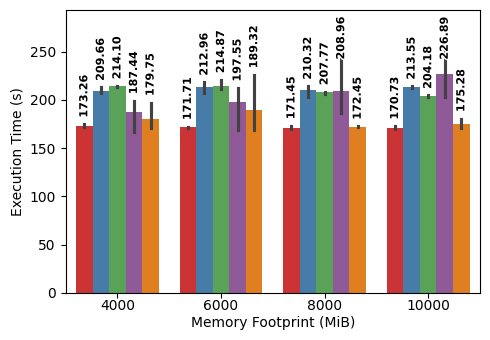

XSBench speedup summary
  4000 MiB
    MANTA (6.2+ kernel) vs ARMS (6.2+ kernel): 173.26s vs 209.66s -> faster by 17.4% (1.21x)
    MANTA (6.2+ kernel) vs best baseline (TPP (5.15+ kernel)): 173.26s vs 179.75s -> faster by 3.6% (1.04x)
  6000 MiB
    MANTA (6.2+ kernel) vs ARMS (6.2+ kernel): 171.71s vs 212.96s -> faster by 19.4% (1.24x)
    MANTA (6.2+ kernel) vs best baseline (TPP (5.15+ kernel)): 171.71s vs 189.32s -> faster by 9.3% (1.10x)
  8000 MiB
    MANTA (6.2+ kernel) vs ARMS (6.2+ kernel): 171.45s vs 210.32s -> faster by 18.5% (1.23x)
    MANTA (6.2+ kernel) vs best baseline (TPP (5.15+ kernel)): 171.45s vs 172.45s -> faster by 0.6% (1.01x)
  10000 MiB
    MANTA (6.2+ kernel) vs ARMS (6.2+ kernel): 170.73s vs 213.55s -> faster by 20.1% (1.25x)
    MANTA (6.2+ kernel) vs best baseline (TPP (5.15+ kernel)): 170.73s vs 175.28s -> faster by 2.6% (1.03x)

bc-kron.sg


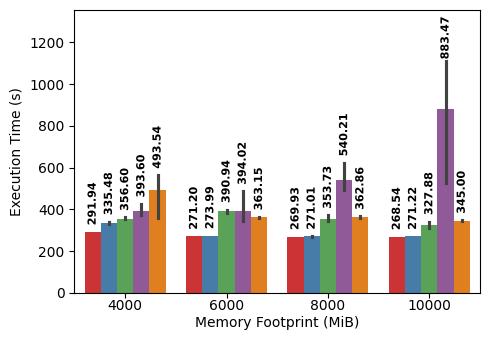

bc-kron.sg speedup summary
  4000 MiB
    MANTA (6.2+ kernel) vs ARMS (6.2+ kernel): 291.94s vs 335.48s -> faster by 13.0% (1.15x)
    MANTA (6.2+ kernel) vs best baseline (HybridTier (6.2+ kernel)): 291.94s vs 356.60s -> faster by 18.1% (1.22x)
  6000 MiB
    MANTA (6.2+ kernel) vs ARMS (6.2+ kernel): 271.20s vs 273.99s -> faster by 1.0% (1.01x)
    MANTA (6.2+ kernel) vs best baseline (TPP (5.15+ kernel)): 271.20s vs 363.15s -> faster by 25.3% (1.34x)
  8000 MiB
    MANTA (6.2+ kernel) vs ARMS (6.2+ kernel): 269.93s vs 271.01s -> faster by 0.4% (1.00x)
    MANTA (6.2+ kernel) vs best baseline (HybridTier (6.2+ kernel)): 269.93s vs 353.73s -> faster by 23.7% (1.31x)
  10000 MiB
    MANTA (6.2+ kernel) vs ARMS (6.2+ kernel): 268.54s vs 271.22s -> faster by 1.0% (1.01x)
    MANTA (6.2+ kernel) vs best baseline (HybridTier (6.2+ kernel)): 268.54s vs 327.88s -> faster by 18.1% (1.22x)

bc-twitter.sg


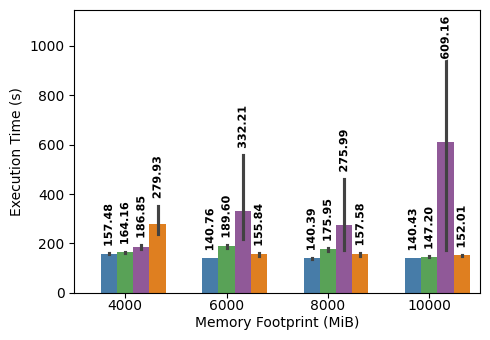

bc-twitter.sg speedup summary

faiss_10M


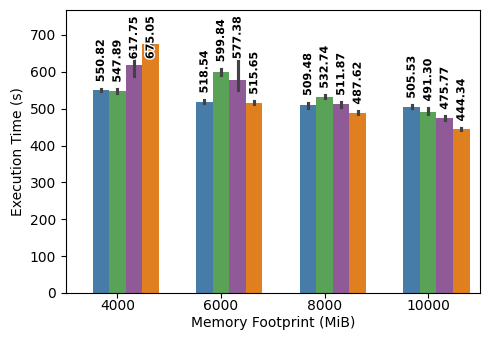

faiss_10M speedup summary

lulesh2.0_s400


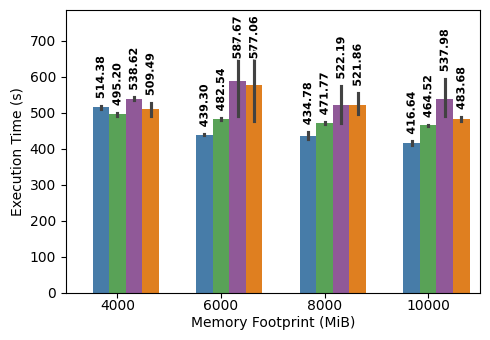

lulesh2.0_s400 speedup summary

mg.D.x


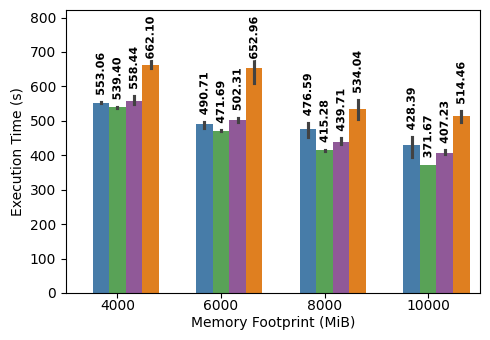

mg.D.x speedup summary

pr-kron.sg


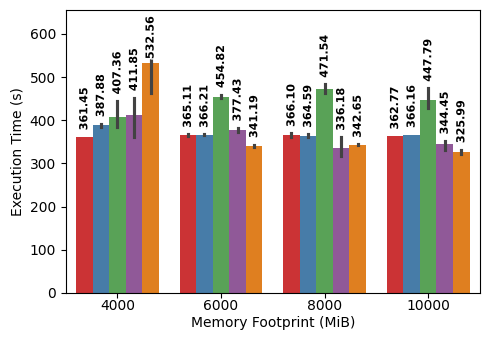

pr-kron.sg speedup summary
  4000 MiB
    MANTA (6.2+ kernel) vs ARMS (6.2+ kernel): 361.45s vs 387.88s -> faster by 6.8% (1.07x)
    MANTA (6.2+ kernel) vs best baseline (HybridTier (6.2+ kernel)): 361.45s vs 407.36s -> faster by 11.3% (1.13x)
  6000 MiB
    MANTA (6.2+ kernel) vs ARMS (6.2+ kernel): 365.11s vs 366.21s -> faster by 0.3% (1.00x)
    MANTA (6.2+ kernel) vs best baseline (TPP (5.15+ kernel)): 365.11s vs 341.19s -> slower by 7.0% (1.07x runtime)
  8000 MiB
    MANTA (6.2+ kernel) vs ARMS (6.2+ kernel): 366.10s vs 364.59s -> slower by 0.4% (1.00x runtime)
    MANTA (6.2+ kernel) vs best baseline (NOMAD (5.13-rc6+ kernel)): 366.10s vs 336.18s -> slower by 8.9% (1.09x runtime)
  10000 MiB
    MANTA (6.2+ kernel) vs ARMS (6.2+ kernel): 362.77s vs 366.16s -> faster by 0.9% (1.01x)
    MANTA (6.2+ kernel) vs best baseline (TPP (5.15+ kernel)): 362.77s vs 325.99s -> slower by 11.3% (1.11x runtime)

pr-twitter.sg


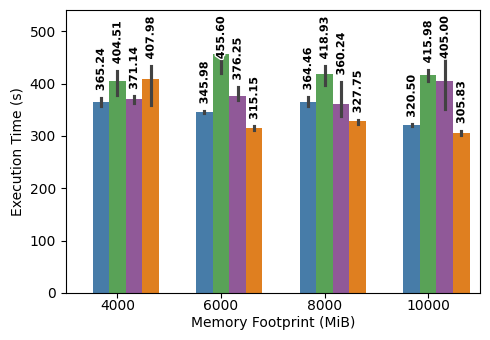

pr-twitter.sg speedup summary



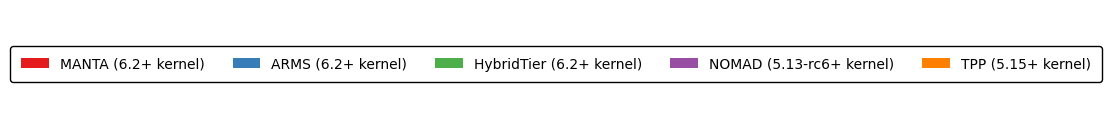

In [19]:
roots_6_2 = lambda workload: {
        #"arms 6.18": ("6.18", Path(f"/users/zimooo2/tiering_solutions/times/arms-6.18/{workload}")),
        "MANTA (6.2+ kernel)": ("6.2+", Path(f"/users/zimooo2/tiering_solutions/times/c220g5/model-6.2/{workload}")),
        "ARMS (6.2+ kernel)": ("6.2+", Path(f"/users/zimooo2/tiering_solutions/times/c220g5/arms-6.2/{workload}")),
        "HybridTier (6.2+ kernel)": ("6.2+", (Path(f"/users/zimooo2/tiering_solutions/times/c220g5/hybridtier/{workload}"))),
        "NOMAD (5.13-rc6+ kernel)": ("5.13-rc6+", Path(f"/users/zimooo2/tiering_solutions/times/c220g5/nomad/{workload}")),
        "TPP (5.15+ kernel)": ("5.15+", Path(f"/users/zimooo2/tiering_solutions/times/c220g5/tpp/{workload}")),
        #"AutoNUMA (6.2+ kernel)": ("6.2+", Path(f"/users/zimooo2/tiering_solutions/times/c220g5/autonuma/{workload}")),
    }

df = generate_df(roots_6_2)
plot_df(df[df["MiB"] > 3000], roots_6_2, figsize=(5, 3.5), title=False, prefix="c220g5_")

DuckDB-TPCDS-sf100


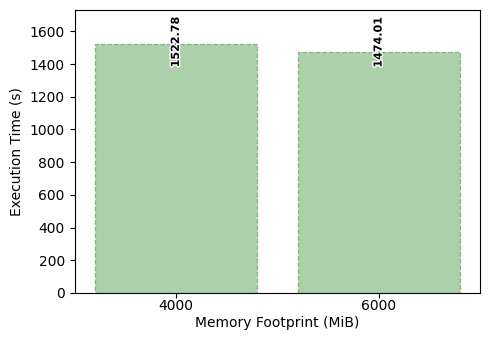

DuckDB-TPCDS-sf100 speedup summary

DuckDB-TPCH-sf100


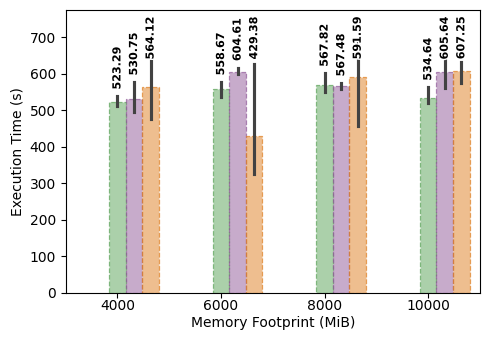

DuckDB-TPCH-sf100 speedup summary

XSBench


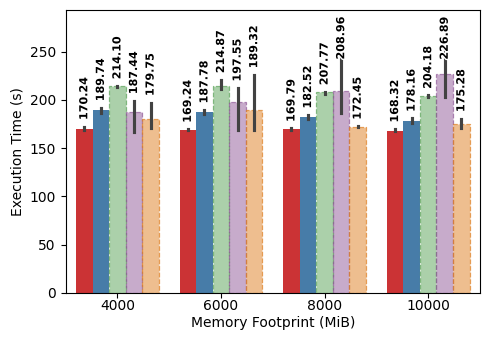

XSBench speedup summary
  4000 MiB
    MANTA (6.18 kernel) vs ARMS (6.18 kernel): 170.24s vs 189.74s -> faster by 10.3% (1.11x)
    MANTA (6.18 kernel) vs best baseline (TPP (5.15+ kernel)): 170.24s vs 179.75s -> faster by 5.3% (1.06x)
  6000 MiB
    MANTA (6.18 kernel) vs ARMS (6.18 kernel): 169.24s vs 187.78s -> faster by 9.9% (1.11x)
    MANTA (6.18 kernel) vs best baseline (TPP (5.15+ kernel)): 169.24s vs 189.32s -> faster by 10.6% (1.12x)
  8000 MiB
    MANTA (6.18 kernel) vs ARMS (6.18 kernel): 169.79s vs 182.52s -> faster by 7.0% (1.07x)
    MANTA (6.18 kernel) vs best baseline (TPP (5.15+ kernel)): 169.79s vs 172.45s -> faster by 1.5% (1.02x)
  10000 MiB
    MANTA (6.18 kernel) vs ARMS (6.18 kernel): 168.32s vs 178.16s -> faster by 5.5% (1.06x)
    MANTA (6.18 kernel) vs best baseline (TPP (5.15+ kernel)): 168.32s vs 175.28s -> faster by 4.0% (1.04x)

bc-kron.sg


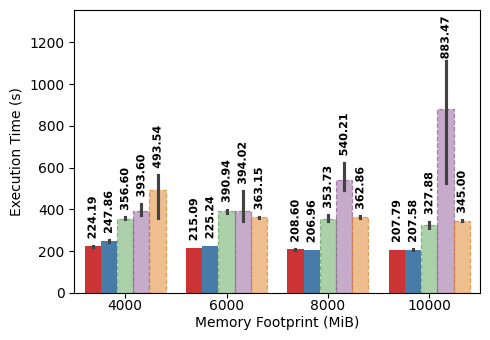

bc-kron.sg speedup summary
  4000 MiB
    MANTA (6.18 kernel) vs ARMS (6.18 kernel): 224.19s vs 247.86s -> faster by 9.5% (1.11x)
    MANTA (6.18 kernel) vs best baseline (HybridTier (6.2+ kernel)): 224.19s vs 356.60s -> faster by 37.1% (1.59x)
  6000 MiB
    MANTA (6.18 kernel) vs ARMS (6.18 kernel): 215.09s vs 225.24s -> faster by 4.5% (1.05x)
    MANTA (6.18 kernel) vs best baseline (TPP (5.15+ kernel)): 215.09s vs 363.15s -> faster by 40.8% (1.69x)
  8000 MiB
    MANTA (6.18 kernel) vs ARMS (6.18 kernel): 208.60s vs 206.96s -> slower by 0.8% (1.01x runtime)
    MANTA (6.18 kernel) vs best baseline (HybridTier (6.2+ kernel)): 208.60s vs 353.73s -> faster by 41.0% (1.70x)
  10000 MiB
    MANTA (6.18 kernel) vs ARMS (6.18 kernel): 207.79s vs 207.58s -> slower by 0.1% (1.00x runtime)
    MANTA (6.18 kernel) vs best baseline (HybridTier (6.2+ kernel)): 207.79s vs 327.88s -> faster by 36.6% (1.58x)

bc-twitter.sg


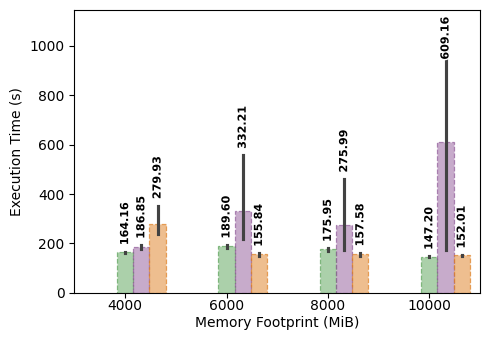

bc-twitter.sg speedup summary

faiss_10M


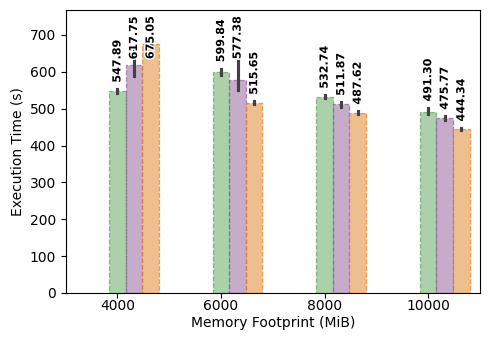

faiss_10M speedup summary

lulesh2.0_s400


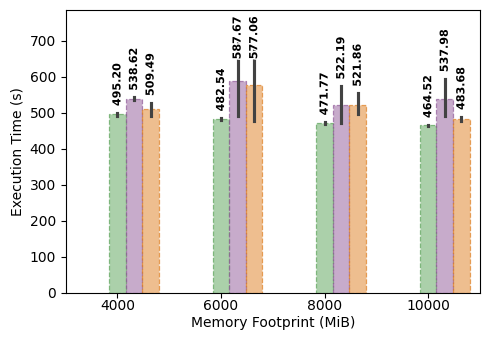

lulesh2.0_s400 speedup summary

mg.D.x


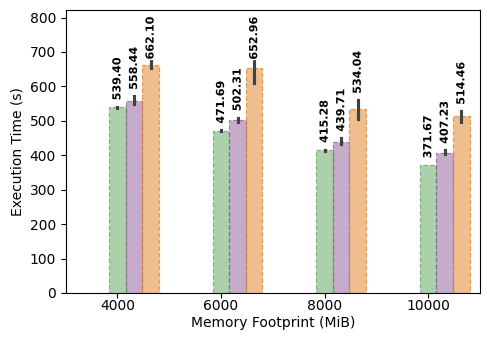

mg.D.x speedup summary

pr-kron.sg


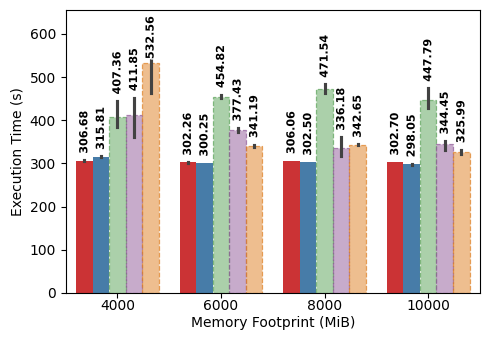

pr-kron.sg speedup summary
  4000 MiB
    MANTA (6.18 kernel) vs ARMS (6.18 kernel): 306.68s vs 315.81s -> faster by 2.9% (1.03x)
    MANTA (6.18 kernel) vs best baseline (HybridTier (6.2+ kernel)): 306.68s vs 407.36s -> faster by 24.7% (1.33x)
  6000 MiB
    MANTA (6.18 kernel) vs ARMS (6.18 kernel): 302.26s vs 300.25s -> slower by 0.7% (1.01x runtime)
    MANTA (6.18 kernel) vs best baseline (TPP (5.15+ kernel)): 302.26s vs 341.19s -> faster by 11.4% (1.13x)
  8000 MiB
    MANTA (6.18 kernel) vs ARMS (6.18 kernel): 306.06s vs 302.50s -> slower by 1.2% (1.01x runtime)
    MANTA (6.18 kernel) vs best baseline (NOMAD (5.13-rc6+ kernel)): 306.06s vs 336.18s -> faster by 9.0% (1.10x)
  10000 MiB
    MANTA (6.18 kernel) vs ARMS (6.18 kernel): 302.70s vs 298.05s -> slower by 1.6% (1.02x runtime)
    MANTA (6.18 kernel) vs best baseline (TPP (5.15+ kernel)): 302.70s vs 325.99s -> faster by 7.1% (1.08x)

pr-twitter.sg


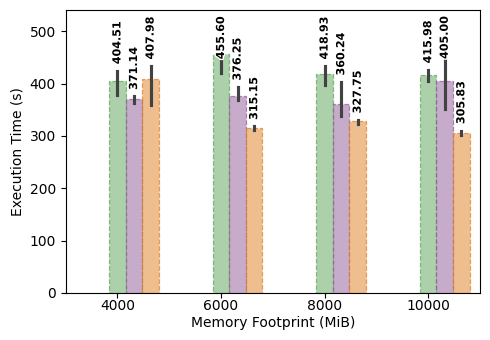

pr-twitter.sg speedup summary



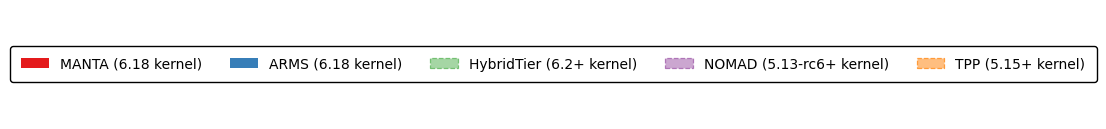

In [26]:
roots_6_18 = lambda workload: {
        "MANTA (6.18 kernel)": ("6.18", Path(f"/users/zimooo2/tiering_solutions/times/c220g5/model/{workload}")),
        "ARMS (6.18 kernel)": ("6.18", Path(f"/users/zimooo2/tiering_solutions/times/c220g5/arms-6.18/{workload}")),
        "HybridTier (6.2+ kernel)": ("6.2+", (Path(f"/users/zimooo2/tiering_solutions/times/c220g5/hybridtier/{workload}"))),
        "NOMAD (5.13-rc6+ kernel)": ("5.13-rc6+", Path(f"/users/zimooo2/tiering_solutions/times/c220g5/nomad/{workload}")),
        "TPP (5.15+ kernel)": ("5.15+", Path(f"/users/zimooo2/tiering_solutions/times/c220g5/tpp/{workload}")),
    }

df = generate_df(roots_6_18)


plot_df(df[df["MiB"] > 3000], roots_6_18, figsize=(5, 3.5), title=False, prefix="6_18_c220g5_", dash_non_arms_non_manta=True)